Rewriting and consolidating the looped data runs and plotting functions. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import pandas as pd
import seaborn as sns


Working with loop test v2 - adjusted the leak parameters and modeled out the super emitter events as episodic; re-running the 1, 2, 5 kg/hr thresholds; plotting up. 

In [46]:
#Set up the path for the FEAST output from the loops: 
path_to_loop_results  = 'run_results_continuous/'
subfolders = [subfold for subfold in os.listdir(path_to_loop_results)]

#Then create the dataframe to catch the output summary data from the runs: 
looped_results = pd.DataFrame(columns = ['program', 'val_avg', 'val_var', 'val_sum','threshold', 'cadence', 'cadence_days'])
counter = -1

#pull the indexs for the last year of data: 
indx_high = 5*365
indx_low = (5*365) - 364

#Conversion factors: 
secPerDay = 60*60*24
gramPerKg = 1000
kgPerUSton = 907.185
nsites = 20

for indx in range(len(subfolders)):

    #split out the info we need from the folder names: 
    split_folder_name = subfolders[indx].split('_')
    threshold = int(split_folder_name[1])
    cadence = split_folder_name[3]
    cadence_days = int(split_folder_name[4])

    #Once you have that subfolder info, pull out the json files within that subfolder: 
    path_to_json = path_to_loop_results + subfolders[indx] + '/'
    json_files = [pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]

    for i in range(len(json_files)):
        read_file = path_to_json + str(json_files[i])
        df = json.load(open(read_file))

        
        #okay - individual file loaded; lets loop through each file and grab the average emissions for each LDAR program. 
        for j in df.keys():
            if j.lower() == "time": #skip the time object
                break
            
            # #Calculate the average emissions value and varainace for the full time series for each LDAR Program: 
            # avg_em = np.mean(np.array(df[j]['emission timeseries'][indx_low:indx_high])) 
            # var_em = np.var(np.array(df[j]['emission timeseries'][indx_low:indx_high])) 
            # sum_em = np.sum(np.array(df[j]['emission timeseries'][indx_low:indx_high])) *(secPerDay/gramPerKg/kgPerUSton/nsites)
            #Calculate the average emissions value and varainace for the full time series for each LDAR Program: 
            avg_em = np.mean(np.array(df[j]['emission timeseries'])) 
            var_em = np.var(np.array(df[j]['emission timeseries'])) 
            sum_em = np.sum(np.array(df[j]['emission timeseries'])) *(secPerDay/gramPerKg/kgPerUSton/nsites)/5

            #Step up the counter: 
            counter += 1 

            #write to location: Not elegent, but I was frustrated with the more sophisticated solutions, 
            # a better python-ist can fix this :) 
            looped_results.at[counter, 'program'] = j
            looped_results.at[counter, 'val_avg'] = avg_em
            looped_results.at[counter, 'val_var'] = var_em
            looped_results.at[counter, 'val_sum'] = sum_em
            looped_results.at[counter, 'threshold'] = threshold
            looped_results.at[counter, 'cadence'] = cadence
            looped_results.at[counter, 'cadence_days'] = cadence_days




In [47]:
# Change the catagorical columns to catagory and re-order: 

looped_results['program'] = looped_results['program'].astype('category')
looped_results['cadence'] = looped_results['cadence'].astype('category')       

reordered = ['monthly', 'bimonthly', 'quarterly', 'semiannual', 'annual']
looped_results['cadence'] = looped_results['cadence'].cat.reorder_categories(reordered, ordered = True)

reordered_programs = ['quarterly_ogi', 'periodic', 'periodic_annual', 'continuous', 'continuous_annual', 'continuous_comp', 'Null']
looped_results['program'] = looped_results['program'].cat.reorder_categories(reordered_programs, ordered = True)

First plot: 5kg threshold, with emission rate in g/s: (change the threshold == value to look at different thresholds)

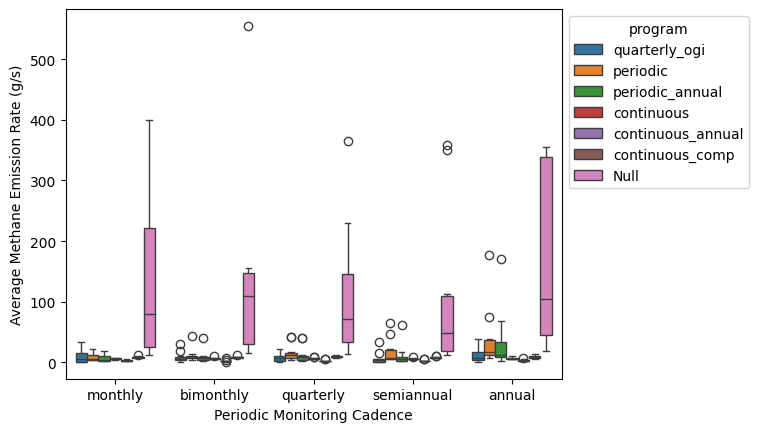

In [48]:
ax = sns.boxplot(data = looped_results[looped_results['threshold'] == 5], x = 'cadence', y = 'val_avg', hue = 'program')
ax.set(xlabel='Periodic Monitoring Cadence', ylabel='Average Methane Emission Rate (g/s)')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))


Next plot: Same thing but with sum emissions

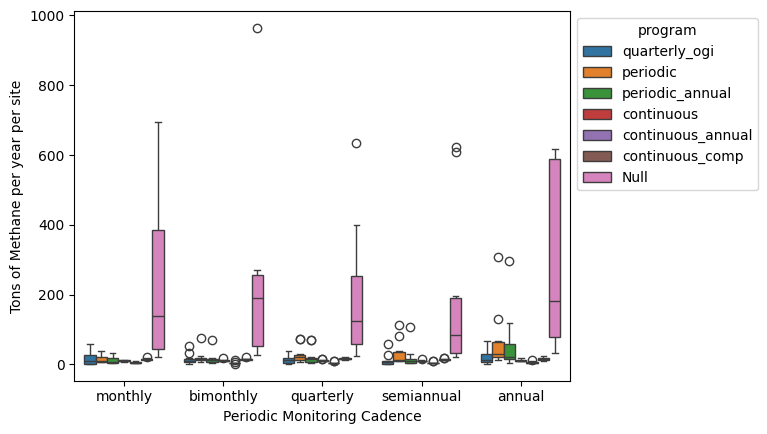

In [49]:
ax = sns.boxplot(data = looped_results[looped_results['threshold'] == 5], x = 'cadence', y = 'val_sum', hue = 'program')
ax.set(xlabel='Periodic Monitoring Cadence', ylabel='Tons of Methane per year per site')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))

Facet out the plots by threshold; 

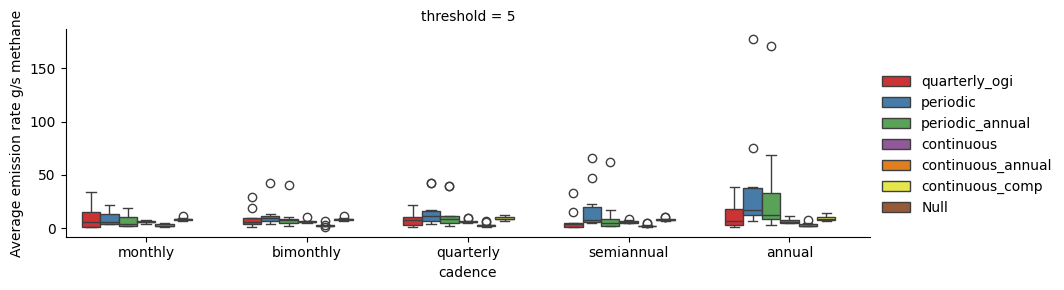

In [50]:
g = sns.FacetGrid(looped_results[looped_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3)
g.map_dataframe(sns.boxplot,  x = 'cadence', y = 'val_avg',  hue = 'program',palette='Set1' ).add_legend().set(ylabel='Average emission rate g/s methane')


Same thing as the sum: 

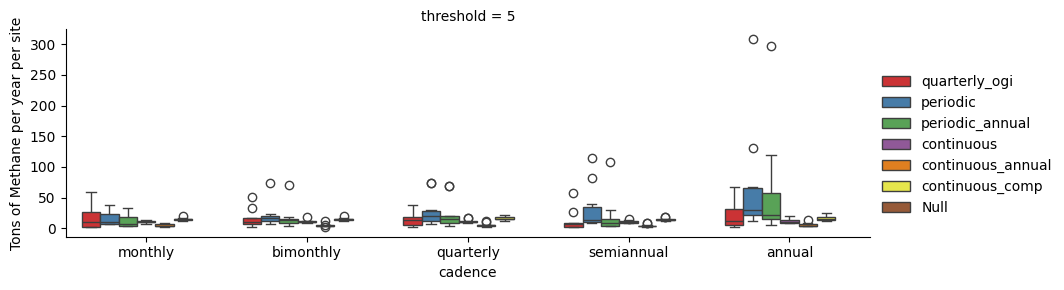

In [51]:
g = sns.FacetGrid(looped_results[looped_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3)
g.map_dataframe(sns.boxplot,  x = 'cadence', y = 'val_sum',  hue = 'program',palette='Set1' ).add_legend().set(ylabel='Tons of Methane per year per site')

Adding a couple of Plots codes: First, individual timeseries from the run set. 

Start with setting the color bars; I puilled these from the FEAST codes, before I switched to seaborn codes. 

In [52]:
# The color set defined here is the Tableau 10 color set.
color_set = np.array([
    [78, 121, 167],
    [242, 142,  43],
    [225,  87,  89],
    [118, 183, 178],
    [89, 161,  79],
    [237, 201, 72],
    [176, 122, 161],
    [255, 157, 167],
    [156, 117,  95],
    [186, 176, 172]
]) /255


Load and plot a single run from the loops

In [70]:
#Load indiviudal run: 
with open('run_results_continuous/Loop_5_kg_quarterly_90/realization6.json') as f:
    runresults = json.load(f)

quarterly_ogi
periodic
periodic_annual
continuous
continuous_annual
continuous_comp
no LDAR


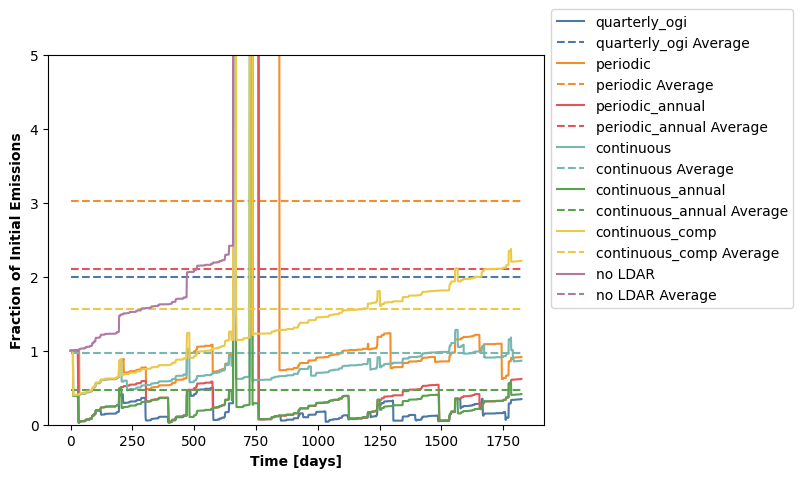

In [72]:
fig = plt.figure()
ax = fig.add_subplot(111)
counter = -1
 
for i in runresults.keys():
    lab = i #set the legend 
    #skip time and also set null to no LDAR
    if i.lower() == "null":
        lab = "no LDAR"
    if i.lower() == "time":
        break
    counter += 1
    print(lab)
    ax.plot(np.array(range(0,runresults['time']['n_timesteps'])), 
            np.array(runresults[i]['emission timeseries']) / runresults["Null"]['emission timeseries'][0], 
            label=lab, color=color_set[counter])
    
    avg_emissions = np.mean(np.array(runresults[i]['emission timeseries'])  / runresults["Null"]['emission timeseries'][0])
    ax.plot([0,runresults['time']['n_timesteps']],np.array([avg_emissions, avg_emissions]), '--', label = lab + ' Average', color = color_set[counter])
    ax.set_ylim([0,5])

plt.xlabel('Time [days]', fontweight = 'bold')
plt.ylabel('Fraction of Initial Emissions', fontweight = 'bold')
plt.legend(loc = 'center left', bbox_to_anchor=(1, 0.72))

Okay, next plot that I'm capturing: the ratioing of each program to the quarterly OGI results. Start with the groupby call, taking the mean of the sums grouped byt program, cadence, and threshold: 

In [61]:
check = looped_results.groupby(['program','cadence', 'threshold'])['val_sum'].mean().reset_index()


C:\Users\hhallida\AppData\Local\Temp\ipykernel_18372\214096957.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  check = looped_results.groupby(['program','cadence', 'threshold'])['val_sum'].mean().reset_index()


once you have the groupby results, we pull out the quarterly_ogi into it's own seperate object, then basically take the difference of the different programs to their own quarterly OGI. This is definitely clunky, I'm certain there's an elegant solution to this somwhere, but this worked well enough for simple plots and low iterations of the model. 


In [62]:

quartogi = check[check['program'] == "quarterly_ogi"]
programs = check[check['program'] != "quarterly_ogi"]

ratioed_results = pd.DataFrame(columns = ['program', 'val', 'threshold', 'cadence'])
counter = -1

for i in range(len(programs)):

    #for each index pull the cadence and threshold: 
    cad = programs.iloc[i, programs.columns.get_loc('cadence')]
    thrs = programs.iloc[i, programs.columns.get_loc('threshold')]
    #Then use those to pull the quarterly OGI row: 
    grab = quartogi[(quartogi['cadence'] == cad) & (quartogi['threshold'] == thrs)]
    #once you have that, calculate the difference (or ratio?): 
    val = pd.to_numeric(programs.iloc[i, programs.columns.get_loc('val_sum')]) - pd.to_numeric(grab['val_sum'].values[0])

    #writeout: 
    counter += 1
    ratioed_results.at[counter, 'program'] = programs.iloc[i, programs.columns.get_loc('program')]
    ratioed_results.at[counter, 'threshold'] = thrs
    ratioed_results.at[counter, 'cadence'] = cad
    ratioed_results.at[counter, 'val'] = val

Plot those ratioed results; 

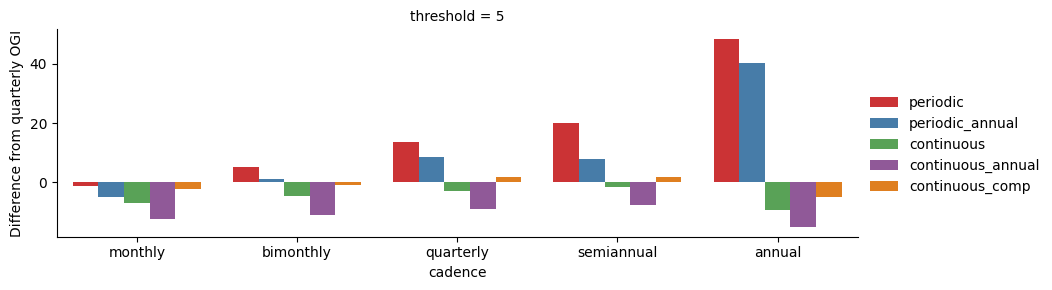

In [63]:
g = sns.FacetGrid(ratioed_results[ratioed_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3, )
g.map_dataframe(sns.barplot,  x = 'cadence', y = 'val',  hue = 'program',palette='Set1' ).add_legend().set(ylabel='Difference from quarterly OGI')

Alternative formulation of that same plot, ogranized by program instead of cadence: 

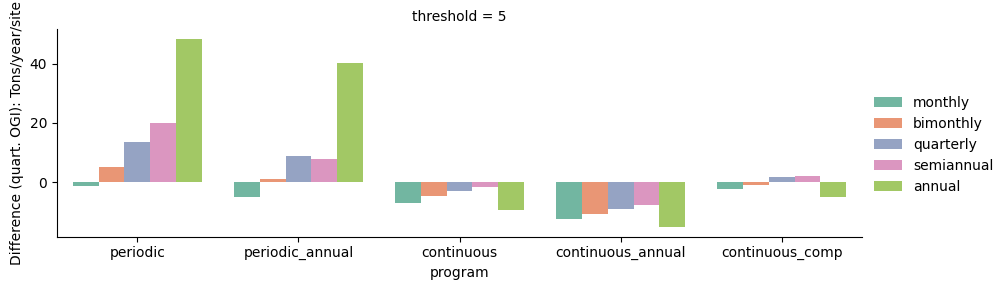

In [64]:
g = sns.FacetGrid(ratioed_results[ratioed_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3, )
g.map_dataframe(sns.barplot,  x = 'program', y = 'val',  hue = 'cadence',palette='Set2' ).add_legend().set(ylabel='Difference (quart. OGI): Tons/year/site')